In [1]:
# To save time, start this download first, before reading through the examples.
import torch, torchvision, os
if not os.path.isfile('datasets/miniplaces/train/yard/00001000.jpg'):
    torchvision.datasets.utils.download_and_extract_archive(
        'http://dissect.csail.mit.edu/datasets/miniplaces.zip',
        'datasets', md5='bfabeb497c7eca01c74cd8441a9ac108')

100%|██████████| 491M/491M [00:47<00:00, 10.2MB/s]


<img src="https://github.com/bshind87/how-to-read-pytorch/blob/master/notebooks/dataloader.png?raw=1" style="max-width:100%">

Datasets and Dataloaders in pytorch
===================================

Data sets can be thought of as big arrays of data.  If the data set is small enough (e.g., MNIST, which has 60,000 28x28 grayscale images), a dataset can be literally represented as an array - or more precisely, as a single pytorch tensor.  With one number per pixel, MNIST takes about 200 megabytes of RAM, which fits comfortably into a modern computer.

But larger-scale datasets like ImageNet or Places365 have more than a million higher-resolution full-color images.  In these cases, an ordinary python array or pytorch tensor would require more than a terabyte of RAM, which is impractical on most computers.

Instead, we need to load the data from disk (or SSD).  Unfortunately, the latency of loading from disk is very slow compared to RAM, so we need to do the loading cleverly if we want to load the data quickly.

To solve the problem, pytorch provides two classes:
 * `torch.utils.data.Dataset` - This very simple base class represents an array where the actual data may be slow to fetch, typically because the data is in disk files that require some loading, decoding, or other preprocessing. Pytorch provides a variety of different `Dataset` subclasses.  For example, there is a handy one called `ImageFolder` that treats a directory tree of image files as an array of classified images.
 * `torch.utils.data.DataLoader` - This fancy class wraps a `Dataset` as a stream of data batches.  Behind the scenes it uses a few techniques to feed the data faster.  You do not need to subclass `DataLoader` - its purpose is to make a `Dataset` speedy.

## Looking at an image data set using ImageFolder

The most common `Dataset` used in computer vision is `ImageFolder`, which loads a set of image files from a directory tree.  It treats every subdirectory of images as a classification category.  To demonstrate it, we will use it to load images from the miniplaces dataset loaded above.

**Directory layout.** Notice that `datasets/miniplaces/val` contains a set of 100 directories with names like `golf_course`.  Each of these directories contains 100 images, each stored as a jpeg file: 10000 images in total.

In [ ]:
ls datasets/miniplaces/val/golf_course

**Constructing an ImageFolder.**  Making an ImageFolder at the root directory of the data set creats an object that behaves like an array: it has a length, and each entry contains a tuple with an image and a number.  The image is stored as a `PIL` object which is a standard python object for images, and the number denotes the classification class - with one class for each folder, numbered in alphabetical order.

Length is 10000
5100th item is a pair (<PIL.Image.Image image mode=RGB size=128x128 at 0x7D767DE934D0>, 51)


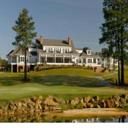

Class name is golf_course


In [2]:
val_set = torchvision.datasets.ImageFolder('datasets/miniplaces/val')
print('Length is', len(val_set))
item = val_set[5100]
print('5100th item is a pair', item)

# Display the PIL image and the class name directly.
display(item[0])
print('Class name is', val_set.classes[item[1]])

**Transforming the PIL image into a pytorch tensor.**  A PIL image is not convenient for training: we would prefer our data set to return pytorch tensors.  So we can tell `ImageFolder` to do this by specifying the `transform` function on construction.  Pytorch comes with a standard transform function `torchvision.transforms.ToTensor()` which converts an image to a pytorch tensor.

Now when indexing into the data set, we will get a pytorch tensor instead of a PIL image.

(tensor([[[0.7569, 0.7608, 0.7765,  ..., 0.6980, 0.6941, 0.7176],
         [0.7569, 0.7608, 0.7765,  ..., 0.7216, 0.7098, 0.7294],
         [0.7569, 0.7647, 0.7804,  ..., 0.7529, 0.7412, 0.7490],
         ...,
         [0.1333, 0.1569, 0.2039,  ..., 0.5176, 0.2588, 0.4902],
         [0.2549, 0.2667, 0.2941,  ..., 0.5137, 0.2824, 0.4353],
         [0.3020, 0.2980, 0.2941,  ..., 0.4745, 0.2588, 0.3569]],

        [[0.6235, 0.6275, 0.6392,  ..., 0.5922, 0.5804, 0.5961],
         [0.6235, 0.6275, 0.6392,  ..., 0.6157, 0.5961, 0.6078],
         [0.6275, 0.6353, 0.6431,  ..., 0.6471, 0.6275, 0.6275],
         ...,
         [0.0980, 0.1216, 0.1569,  ..., 0.4706, 0.2078, 0.4392],
         [0.2078, 0.2196, 0.2353,  ..., 0.4667, 0.2314, 0.3922],
         [0.2431, 0.2392, 0.2314,  ..., 0.4275, 0.2157, 0.3137]],

        [[0.5137, 0.5176, 0.5294,  ..., 0.4863, 0.4627, 0.4745],
         [0.5137, 0.5176, 0.5294,  ..., 0.5098, 0.4784, 0.4863],
         [0.5059, 0.5137, 0.5255,  ..., 0.5333, 0.5098, 0

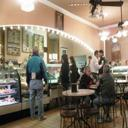

In [3]:
val_set =  torchvision.datasets.ImageFolder(
    'datasets/miniplaces/val',
    transform=torchvision.transforms.ToTensor())
print(val_set[1000])

# There is an inverse transform that can be used to convert it back to a PIL image,
# handy if we want to see it.
as_image = torchvision.transforms.ToPILImage()
display(as_image(val_set[1000][0]))

## Fast Dataset Access using DataLoader

When we use a dataset for training, we will usually run through the whole dataset in batches.  We could do this ourselves, as in line 6-8 below, by just fetching the images one at a time and grouping them.

But a faster way to iterate through the dataset is to wrap our `val_set` object in a `torch.utils.data.DataLoader` object, as shown on line 14-18 below.  The `val_loader` we get can magically pull data out of the Dataset much  faster than doing it in the smiple way; the `DataLoader` class does this by using several threads to load and prefetch the data.

The speedup will depend on the system and the number of threads you use (the number of threads to use is specified using `num_workers`).  In practice using `DataLoader` will typically be 5-20 times faster than direct `Dataset` access.

In [4]:
import time

print('Going over the data set as an array.')
start = time.time()
summed_image_dataset = 0
batch_size = 100
for i in range(0, len(val_set), batch_size):
    image_batch = torch.stack([val_set[i+j][0] for j in range(batch_size)])
    summed_image_dataset += image_batch.sum(0)
end = time.time()
print(f'Took {end - start} seconds')

print('Going over the same dataset using a dataloader.')
start = time.time()
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=batch_size, num_workers=10)
summed_image_loader = 0
for image_batch, label_batch in val_loader:
    summed_image_loader += image_batch.sum(0)
end = time.time()
print(f'Took {end - start} seconds')

print('Numerical difference is exactly', (summed_image_loader - summed_image_dataset).norm().item())

Going over the data set as an array.
Took 6.4914631843566895 seconds
Going over the same dataset using a dataloader.


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 10 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Took 6.922124147415161 seconds
Numerical difference is exactly 0.0


### Exercise

1. Try adjusting `num_workers` down to 1 and up to 100.  How does this affect the speed?
2. Try changing `batch_size` down to 1 or up to 1000.

**Note**: the speed differences you see will depend on the specifics of your system setup.
If you are running on Google Colab, you may not see much of a speedup from DataLoader.
This is because Colab provides a very low-latency virtual disk (so direct Dataset access
is faster than on a regular computer), and a virtual CPU with very slow concurrency
(so DataLoader multithreading is slower than normal).

In [5]:
# TODO: copy the code above and alter:
# 1. num_workers and note the changes in speed
# 2. batch_size and note the changes in speed.
import time

def time_direct(batch_size):
    # Plain Dataset access, one image at a time on this thread.
    start = time.time()
    total = 0
    for i in range(0, len(val_set) - batch_size + 1, batch_size):
        image_batch = torch.stack([val_set[i+j][0] for j in range(batch_size)])
        total += image_batch.sum(0)
    return time.time() - start

def time_loader(batch_size, num_workers):
    loader = torch.utils.data.DataLoader(
        val_set, batch_size=batch_size, num_workers=num_workers)
    start = time.time()
    total = 0
    for image_batch, label_batch in loader:
        total += image_batch.sum(0)
    return time.time() - start

# Heads up: this whole cell walks the 10000-image validation set about ten times,
# so expect it to take a few minutes.
print(f'direct Dataset access, batch_size=100: {time_direct(100):.1f} sec\n')

# 1. Vary num_workers, holding batch_size at 100.
for num_workers in [1, 2, 5, 10, 20, 100]:
    elapsed = time_loader(100, num_workers)
    print(f'DataLoader batch_size=100  num_workers={num_workers:<4} {elapsed:.1f} sec')
print()

# 2. Vary batch_size, holding num_workers at 10.
for batch_size in [1, 10, 100, 1000]:
    elapsed = time_loader(batch_size, 10)
    print(f'DataLoader num_workers=10  batch_size={batch_size:<5} {elapsed:.1f} sec')

print()
print('What to expect: more workers helps until it saturates the machine, because each')
print('worker is mostly sitting idle waiting on disk and jpeg decoding.  Past the number')
print('of cores the extra workers only add scheduling and memory overhead, and 100')
print('workers is usually slower than 10 -- on Colab, whose virtual CPU concurrency is')
print('poor, even a handful of workers may not beat direct access at all.')
print('batch_size=1 is the slowest by far: per-batch overhead (collating, queueing,')
print('one python round trip per image) dominates when each batch is a single image.')
print('From about 100 upward the curve flattens out -- the loading cost is already')
print('amortized, and bigger batches just use more memory.')

direct Dataset access, batch_size=100: 6.3 sec

DataLoader batch_size=100  num_workers=1    7.6 sec
DataLoader batch_size=100  num_workers=2    5.6 sec


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 5 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


DataLoader batch_size=100  num_workers=5    5.4 sec
DataLoader batch_size=100  num_workers=10   6.7 sec


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 20 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


DataLoader batch_size=100  num_workers=20   6.0 sec


/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 100 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()
/usr/local/lib/python3.13/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 100 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


DataLoader batch_size=100  num_workers=100  13.1 sec

DataLoader num_workers=10  batch_size=1     21.7 sec
DataLoader num_workers=10  batch_size=10    6.8 sec
DataLoader num_workers=10  batch_size=100   7.0 sec
DataLoader num_workers=10  batch_size=1000  6.3 sec

What to expect: more workers helps until it saturates the machine, because each
worker is mostly sitting idle waiting on disk and jpeg decoding.  Past the number
of cores the extra workers only add scheduling and memory overhead, and 100
workers is usually slower than 10 -- on Colab, whose virtual CPU concurrency is
poor, even a handful of workers may not beat direct access at all.
batch_size=1 is the slowest by far: per-batch overhead (collating, queueing,
one python round trip per image) dominates when each batch is a single image.
From about 100 upward the curve flattens out -- the loading cost is already
amortized, and bigger batches just use more memory.


**Other common dataloader tricks.**  `DataLoader` can do a few more useful things.

 * Although a DataLoader does not put batches on the GPU directly (because of multithreading limitations), it *can* put the batch in pinned memory, which is faster to copy to the GPU later after you get it out of the DataLoader.  Make the DataLoader with `pin_memory=True` for this.
 * During training you usually do not want the batches in alphabetical order.  The DataLoader can shuffle the batches so that they are randomized, instead of sequential.  `shuffle=True` for this.




## Using a DataLoader for Training

We can put everything together by using the data from a data loader to train a classifier.

The following is a simplistic example of training an image classifier.  It uses the Adam optimizer and the ResNet-18 neural network architecture, and trains for a couple minutes, just passing once over the training set.

In [6]:
from tqdm import tqdm

# Create a Dataset of miniplaces training images.
train_set = torchvision.datasets.ImageFolder(
    'datasets/miniplaces/train',
    torchvision.transforms.ToTensor())

# Wrap the Dataset in a high-speed DataLoader with batch_size 100.
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=100, num_workers=10,
    shuffle=True,
    pin_memory=True)

# Create an untrained neural network using the ResNet 18 architecture.
model = torchvision.models.resnet18(num_classes=100).cuda()

# Set up the model for training using the Adam optimizer.
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# To train, optimize an objective on batches of training data.
# Here we look at every training image once.
for batch in tqdm(train_loader):
    images, labels = [d.cuda() for d in batch]
    optimizer.zero_grad()
    scores = model(images.cuda())
    loss = torch.nn.functional.cross_entropy(scores, labels)
    loss.backward()
    optimizer.step()

100%|██████████| 1000/1000 [01:55<00:00,  8.67it/s]


## Checking Accuracy with a Held-Out Dataset

To check if network has learned anything useful, we can check whether the model can make good predictions on unseen images.  The easy way to do this is to create a second `ImageFolder` dataset (and `DataLoader`) with a second set of images that was **not** used for training.

While the achieved accuracy after a couple minutes of training is not perfect, it is already much better than random.

In [7]:
# Create a validation dataset and data loader.
val_set = torchvision.datasets.ImageFolder(
    'datasets/miniplaces/val',
    torchvision.transforms.ToTensor())
val_loader = torch.utils.data.DataLoader(
    val_set, batch_size=100, num_workers=10,
    pin_memory=True)

# This function runs over the validation images and counts accurate predictions.
def accuracy():
    model.eval()
    correct = 0
    for iter, batch in enumerate(val_loader):
        images, labels = [d.cuda() for d in batch]
        with torch.no_grad():
            scores = model(images.cuda())
        correct += (scores.max(1)[1] == labels).float().sum()
    return correct.item() / len(val_set)

print(f'Accuracy on unseen images {accuracy() * 100}% (random guesses would be 1%)')

Accuracy on unseen images 11.200000000000001% (random guesses would be 1%)


### Exercise

1. For every 10th batch, display the first image in the batch.
2. Also print the predicted class name and the true class name for that image.

Hints:
* Use the `as_image` function defined in a previous cell.
* Use `images[0].cpu()` to move the image to the CPU before displaying it.
* The prediction of the network for the 0th item of the batch is `scores.max(1)[1][0]`
* Use `val_set.classes[pred]` to convert the numerical prediction to a readable label.

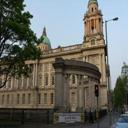

batch 0: predicted "abbey", true "abbey"


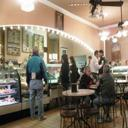

batch 10: predicted "gas_station", true "bakery-shop"


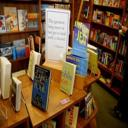

batch 20: predicted "kitchen", true "bookstore"


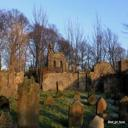

batch 30: predicted "rock_arch", true "cemetery"


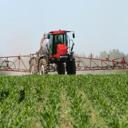

batch 40: predicted "corn_field", true "corn_field"


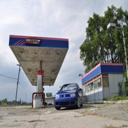

batch 50: predicted "ski_slope", true "gas_station"


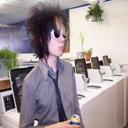

batch 60: predicted "ski_slope", true "laundromat"


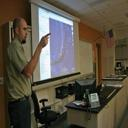

batch 70: predicted "skyscraper", true "office"


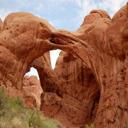

batch 80: predicted "rock_arch", true "rock_arch"


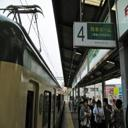

batch 90: predicted "slum", true "subway_station-platform"


In [8]:
# 1. For every 10th batch, display the first image in the batch.
# 2. Also print the predicted class name and the true class name for that image.
as_image = torchvision.transforms.ToPILImage()

def show_predictions(every=10):
    # val_loader is not shuffled, so this picks the same images every time it runs,
    # which makes it easy to compare predictions before and after more training.
    model.eval()
    for iter, batch in enumerate(val_loader):
        if iter % every != 0:
            continue
        images, labels = [d.cuda() for d in batch]
        with torch.no_grad():
            scores = model(images)
        pred = scores.max(1)[1][0]
        display(as_image(images[0].cpu()))
        print(f'batch {iter}: predicted "{val_set.classes[pred]}",'
              f' true "{val_set.classes[labels[0]]}"')

show_predictions()

## Improving Training using Data Augmentation

One of the main ways to stretch a data set to make it more effective for training is to randomly adjust the images.  For example if we randomly adjust the crop, color, or orientation of the image while loading, using the same image file multiple times will produce different training examples for the network.  This is an easy way to increase the amount of training diversity in the data set without requring more actual images.

To do data augmentation in a pytorch `Dataset`, you can specify more operations on `transform=` besides `ToTensor()`.

In particular, there is a `Compose` transform that makes it easy to chain a series of data transformations; and `torchvision.transforms` includes a number of useful image transforms such as random resized crops and image flips.

Here is an example:

In [9]:
# Create a Dataset of miniplaces training images.
train_set = torchvision.datasets.ImageFolder(
    'datasets/miniplaces/train',
    torchvision.transforms.Compose([
        torchvision.transforms.RandomCrop(112),
        torchvision.transforms.RandomHorizontalFlip(),
        torchvision.transforms.ToTensor(),
    ]))
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=100, num_workers=10,
    shuffle=True,
    pin_memory=True)

# Now let's train for one more epoch, and test the accuracy
model.train()
for batch in tqdm(train_loader):
    images, labels = [d.cuda() for d in batch]
    optimizer.zero_grad()
    scores = model(images.cuda())
    loss = torch.nn.functional.cross_entropy(scores, labels)
    loss.backward()
    optimizer.step()
print(f'Accuracy on unseen images {accuracy() * 100}% (random guesses would be 1%)')

100%|██████████| 1000/1000 [01:42<00:00,  9.76it/s]


Accuracy on unseen images 18.8% (random guesses would be 1%)


### Exercise

1. Print out the same images as before, with updated predictions for the newly tuned network parameters.
2. Repeat training for a few more epochs.  How does the accuracy evolve?

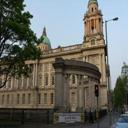

batch 0: predicted "chalet", true "abbey"


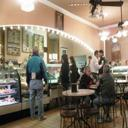

batch 10: predicted "supermarket", true "bakery-shop"


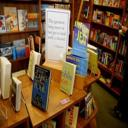

batch 20: predicted "candy_store", true "bookstore"


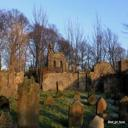

batch 30: predicted "canyon", true "cemetery"


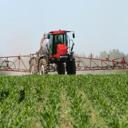

batch 40: predicted "golf_course", true "corn_field"


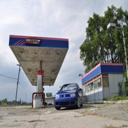

batch 50: predicted "amusement_park", true "gas_station"


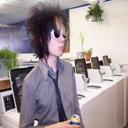

batch 60: predicted "hospital_room", true "laundromat"


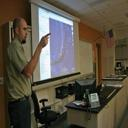

batch 70: predicted "hospital_room", true "office"


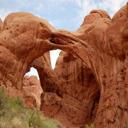

batch 80: predicted "canyon", true "rock_arch"


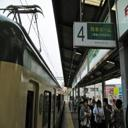

batch 90: predicted "subway_station-platform", true "subway_station-platform"
starting accuracy 18.80%


epoch 1: 100%|██████████| 1000/1000 [01:43<00:00,  9.65it/s]


after epoch 1: accuracy 25.91% (random guesses would be 1%)


epoch 2: 100%|██████████| 1000/1000 [01:43<00:00,  9.71it/s]


after epoch 2: accuracy 18.11% (random guesses would be 1%)


epoch 3: 100%|██████████| 1000/1000 [01:42<00:00,  9.76it/s]


after epoch 3: accuracy 23.83% (random guesses would be 1%)


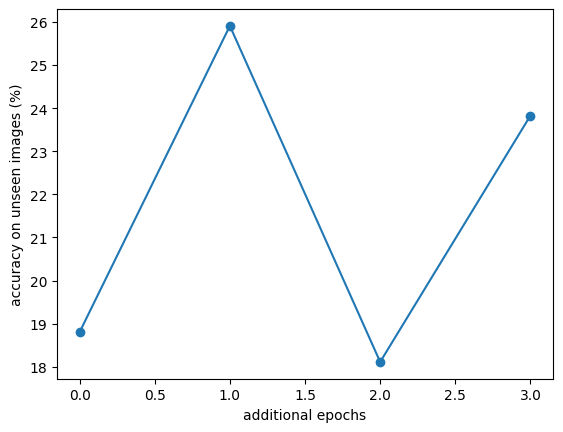

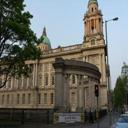

batch 0: predicted "temple-east_asia", true "abbey"


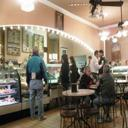

batch 10: predicted "food_court", true "bakery-shop"


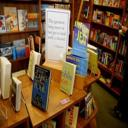

batch 20: predicted "food_court", true "bookstore"


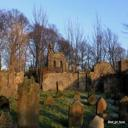

batch 30: predicted "aquarium", true "cemetery"


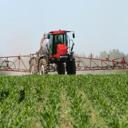

batch 40: predicted "racecourse", true "corn_field"


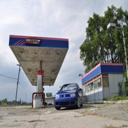

batch 50: predicted "swimming_pool-outdoor", true "gas_station"


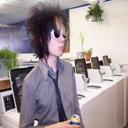

batch 60: predicted "martial_arts_gym", true "laundromat"


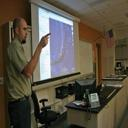

batch 70: predicted "staircase", true "office"


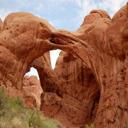

batch 80: predicted "rock_arch", true "rock_arch"


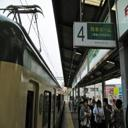

batch 90: predicted "subway_station-platform", true "subway_station-platform"
How the accuracy evolves: the first epochs buy the most, then the gains get
small and bumpy.  Two things are fighting here.  Random crops and flips keep
feeding the network fresh variations, so it keeps improving longer than it
would on the raw images -- but lr=0.01 is a large step size for Adam on a
ResNet, so the accuracy jumps around from epoch to epoch instead of settling.
Decaying the learning rate (see the lr_scheduler note in notebook 3) is the
usual next move once the curve flattens like this.


In [10]:
# 1. Print out the same images as before, with updated predictions.
show_predictions()

# 2. Repeat training for a few more epochs.  How does the accuracy evolve?
# Each epoch over the augmented training set takes a couple of minutes on a GPU,
# so keep `epochs` small unless you want to wait.
epochs = 3
history = [accuracy()]
print(f'starting accuracy {history[0] * 100:.2f}%')

for epoch in range(epochs):
    model.train()
    for batch in tqdm(train_loader, desc=f'epoch {epoch + 1}'):
        images, labels = [d.cuda() for d in batch]
        optimizer.zero_grad()
        scores = model(images)
        loss = torch.nn.functional.cross_entropy(scores, labels)
        loss.backward()
        optimizer.step()
    history.append(accuracy())
    print(f'after epoch {epoch + 1}: accuracy {history[-1] * 100:.2f}%'
          f' (random guesses would be 1%)')

from matplotlib import pyplot as plt
plt.plot(range(len(history)), [a * 100 for a in history], marker='o')
plt.xlabel('additional epochs')
plt.ylabel('accuracy on unseen images (%)')
plt.show()

# The same images once more, now with the further-trained parameters.
show_predictions()

print('How the accuracy evolves: the first epochs buy the most, then the gains get')
print('small and bumpy.  Two things are fighting here.  Random crops and flips keep')
print('feeding the network fresh variations, so it keeps improving longer than it')
print('would on the raw images -- but lr=0.01 is a large step size for Adam on a')
print('ResNet, so the accuracy jumps around from epoch to epoch instead of settling.')
print('Decaying the learning rate (see the lr_scheduler note in notebook 3) is the')
print('usual next move once the curve flattens like this.')

### Epilog

Almost all the pytorch code you will find will be variations and extensions of the patterns we have covered.  You're ready to explore.

Have fun!

### [Back to the introduction &rightarrow;](1-Pytorch-Introduction.ipynb)